<a href="https://colab.research.google.com/github/CassioLima09/NLP_with_Transformers/blob/main/06_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Uncomment and run this cell if you're on Colab or Kaggle
!git clone https://github.com/nlp-with-transformers/notebooks.git
%cd notebooks
from install import *
install_requirements(is_chapter6=True)

Cloning into 'notebooks'...
remote: Enumerating objects: 530, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 530 (delta 184), reused 162 (delta 162), pack-reused 320 (from 2)
Receiving objects: 100% (530/530), 28.52 MiB | 12.14 MiB/s, done.
Resolving deltas: 100% (253/253), done.
/content/notebooks
⏳ Installing base requirements ...
✅ Base requirements installed!
⏳ Installing Git LFS ...
✅ Git LFS installed!


In [ ]:
#hide
from utils import *
setup_chapter()

Using transformers v4.16.2
Using datasets v2.0.0


In [ ]:
# hide
from transformers import pipeline, set_seed

# Summarization

## The CNN/DailyMail Dataset

In [ ]:
#hide_output
# esse é um dataset com mais de 300 mil artigos e seus respectivos resumos
from datasets import load_dataset

dataset = load_dataset("cnn_dailymail", version="3.0.0")
print(f"Features: {dataset['train'].column_names}")

# temos 3 colunas, article, highlights (o resumo em si) e id

Extracting data files:   0%|          | 0/5 [00:00<?, ?it/s]

NotADirectoryError: [Errno 20] Not a directory: '/root/.cache/huggingface/datasets/downloads/1bc05d24fa6dda2468e83a73cf6dc207226e01e3c48a507ea716dc0421da583b/cnn/stories'

In [ ]:
sample = dataset["train"][1]
print(f"""
Article (excerpt of 500 characters, total length: {len(sample["article"])}):
""")
print(sample["article"][:500])
print(f'\nSummary (length: {len(sample["highlights"])}):')
print(sample["highlights"])


Article (excerpt of 500 characters, total length: 3192):

(CNN) -- Usain Bolt rounded off the world championships Sunday by claiming his
third gold in Moscow as he anchored Jamaica to victory in the men's 4x100m
relay. The fastest man in the world charged clear of United States rival Justin
Gatlin as the Jamaican quartet of Nesta Carter, Kemar Bailey-Cole, Nickel
Ashmeade and Bolt won in 37.36 seconds. The U.S finished second in 37.56 seconds
with Canada taking the bronze after Britain were disqualified for a faulty
handover. The 26-year-old Bolt has n

Summary (length: 180):
Usain Bolt wins third gold of world championship .
Anchors Jamaica to 4x100m relay victory .
Eighth gold at the championships for Bolt .
Jamaica double up in women's 4x100m relay .


## Text Summarization Pipelines

In [ ]:
sample_text = dataset["train"][1]["article"][:2000]
# We'll collect the generated summaries of each model in a dictionary
summaries = {}
# vamos testar varios metodos e para isso vamos inicialmente limitar o input em 2000 caracteres

NameError: name 'dataset' is not defined

In [ ]:
#hide_output
import nltk
from nltk.tokenize import sent_tokenize # é usado para separar sentenças (frases)

nltk.download("punkt")
# Este pacote contém modelos e regras que ajudam a NLTK a identificar de forma inteligente
#  onde terminam as sentenças, mesmo em casos complexos (como abreviações, por exemplo, "Sr.", "Sra.", etc.).
#   o comando download("punkt") baixa esses dados necessários
#  do servidor da NLTK e os armazena localmente para que a função sent_tokenize possa usá-los.

[nltk_data] Downloading package punkt to /home/leandro/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
string = "The U.S. are a country. The U.N. is an organization."
sent_tokenize(string)

['The U.S. are a country.', 'The U.N. is an organization.']

### Summarization Baseline


In [ ]:
#Vamos pegar apenas as 3 primeiras sentenças do artigo para testar em varias LLM e ver como resumem

# Define uma função para criar o resumo de três frases
def three_sentence_summary(text):
    # 1. Divide o texto em sentenças usando o sent_tokenize (que você preparou antes)
    sentences = sent_tokenize(text)
    # 2. Pega as 3 primeiras sentenças da lista (ou menos, se o texto tiver menos de 3)
    # sao 3 sentenças completas, até o ponto final, nao sendo impactado por pontos como U.S. ou 3.7
    first_three_sentences = sentences[:3]
    # 3. Junta essas 3 sentenças de volta em uma única string,
    #    separando cada sentença com um caractere de nova linha ("\n")
    summary = "\n".join(first_three_sentences)
    # 4. Retorna o resumo criado
    return summary

# (Assumindo que 'summaries' é um dicionário e 'sample_text' contém o texto do artigo)
# Chama a função com o texto de exemplo ('sample_text')
# e armazena o resultado no dicionário 'summaries' com a chave "baseline"
summaries["baseline"] = three_sentence_summary(sample_text)

In [ ]:
summaries["baseline"] = three_sentence_summary(sample_text)

### GPT-2

We’ve already seen in Chapter 5 how GPT-2 can generate text given some prompt. One of the model’s surprising features is that we can also use it to generate summaries by simply appending “TL;DR” at the end of the input text. The expression “TL;DR” (too long; didn’t read) is often used on platforms like Reddit to indicate a short version of a long post

TL;DR é uma sigla da internet para "Too Long; Didn't Read" (Muito Longo; Não Li), usada comumente para introduzir um resumo. Ao adicionar isso, você está dando uma dica forte ao GPT-2 de que ele deve gerar um resumo do texto que veio antes. É uma técnica comum de prompt engineering.

In [ ]:
#hide_output
from transformers import pipeline, set_seed

set_seed(42)
pipe = pipeline("text-generation", model="gpt2-xl")
gpt2_query = sample_text + "\nTL;DR:\n"   # adicionamos ntl;DR para indicar que iremos sumarizar
pipe_out = pipe(gpt2_query, max_length=512, clean_up_tokenization_spaces=True)
#clean_up_tokenization_spaces=True: Uma opção do pipeline para tentar remover espaços extras que
#podem surgir durante o processo de tokenização/detokenização, melhorando a legibilidade do texto final.
summaries["gpt2"] = "\n".join(
    sent_tokenize(pipe_out[0]["generated_text"][len(gpt2_query) :])) # armazena a resposta do gpt (resumo do texto)
#sent_tokenize(...): Pega essa parte gerada e a divide em sentenças usando o tokenizador da NLTK (o mesmo usado para o baseline).
#Here we just store the summaries of the generated text by slicing off the input
# query and keep the result in a Python dictionary for later comparison

### T5

<img alt="T5" width="700" caption="Diagram of T5's text-to-text framework (courtesy of Colin Raffel); besides translation and summarization, the CoLA (linguistic acceptability) and STSB (semantic similarity) tasks are shown" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_t5.png?raw=1" id="T5"/>

In [ ]:
#hide_output
#Quando você chama pipeline("tarefa", model="modelo"), o primeiro argumento ("tarefa") diz à biblioteca o que você quer fazer.
pipe = pipeline("summarization", model="t5-large") # ja tem tarefa summarization
pipe_out = pipe(sample_text)
summaries["t5"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

### BART

In [ ]:
#hide_output
pipe = pipeline("summarization", model="facebook/bart-large-cnn")
pipe_out = pipe(sample_text)
summaries["bart"] = "\n".join(sent_tokenize(pipe_out[0]["summary_text"]))

### PEGASUS

<img alt="pegasus" width="700" caption="Diagram of PEGASUS architecture (courtesy of Jingqing Zhang et al.)" src="https://github.com/CassioLima09/NLP_with_Transformers/blob/main/images/chapter08_pegasus.png?raw=1" id="pegasus"/>

In [ ]:
#hide_output
pipe = pipeline("summarization", model="google/pegasus-cnn_dailymail")
pipe_out = pipe(sample_text)
summaries["pegasus"] = pipe_out[0]["summary_text"].replace(" .<n>", ".\n")

## Comparing Different Summaries

In [ ]:
print("GROUND TRUTH")
print(dataset["train"][1]["highlights"])
print("")

for model_name in summaries:
    print(model_name.upper())
    print(summaries[model_name])
    print("")

GROUND TRUTH
Usain Bolt wins third gold of world championship .
Anchors Jamaica to 4x100m relay victory .
Eighth gold at the championships for Bolt .
Jamaica double up in women's 4x100m relay .

BASELINE
(CNN) -- Usain Bolt rounded off the world championships Sunday by claiming his
third gold in Moscow as he anchored Jamaica to victory in the men's 4x100m
relay.
The fastest man in the world charged clear of United States rival Justin Gatlin
as the Jamaican quartet of Nesta Carter, Kemar Bailey-Cole, Nickel Ashmeade and
Bolt won in 37.36 seconds.
The U.S finished second in 37.56 seconds with Canada taking the bronze after
Britain were disqualified for a faulty handover.

GPT2
Nesta, the fastest man in the world.
Gatlin, the most successful Olympian ever.
Kemar, a Jamaican legend.
Shelly-Ann, the fastest woman ever.
Bolt, the world's greatest athlete.
The team sport of pole vaulting

T5
usain bolt wins his third gold medal of the world championships in the men's
4x100m relay .
the 26-yea

veja que o Chat GPT alucinou muito, mesmo indicando ao final do prompt que queíamos sumarizar

## Measuring the Quality of Generated Text

Vamos aprender sobre métricas que comparam o desempenho de diferentes saídas de modelos de LLM

### BLEU
Two of the most common metrics used to evaluate generated text are BLEU and ROUGE. Let’s take a look at how they’re defined.

The idea of BLEU is simple: instead of looking at how many of the tokens in the generated texts are perfectly aligned with the reference text tokens, we look at words or n-grams. BLEU is a precision-based metric, which means that when we compare the two texts we count the number of words in the generation that occur in the reference and divide it by the length of the reference


However, there is an issue with this vanilla precision. Assume the generated text just repeats the same word over and over again, and this word also appears in the reference. If it is repeated as many times as the length of the reference text, then we get perfect precision! For this reason, the authors of the BLEU paper introduced a slight modification: a word is only counted as many times as it occurs in the reference. To illustrate this point, suppose we have the reference text “the cat is on the mat” and the generated text “the the the the the

Olá! Com certeza. Avaliar a qualidade das respostas geradas por Modelos de Linguagem Grandes (LLMs) é um desafio crucial, especialmente em tarefas como sumarização, tradução automática, ou geração de texto a partir de dados. Duas das métricas automáticas mais conhecidas e utilizadas para isso são **BLEU** e **ROUGE**.

Vamos mergulhar em uma aula completa sobre elas, considerando o contexto atual (1 de abril de 2025).

---

**Aula Completa: Avaliando LLMs com BLEU e ROUGE**

**1. Por Que Precisamos de Métricas de Avaliação?**

LLMs podem gerar textos incrivelmente fluentes e coerentes. No entanto, precisamos saber:
* Quão *relevante* é a resposta gerada para a entrada?
* Quão *precisa* ou *fiel* ela é a um texto de referência (em tradução ou sumarização)?
* Quão *informativa* ela é (no caso de sumarização)?

A avaliação humana é o "padrão ouro", pois podemos julgar nuances como coerência, relevância, ausência de alucinações (informações inventadas), etc. No entanto, a avaliação humana é:
* **Lenta:** Demora para avaliar muitas saídas.
* **Cara:** Requer pagamento de avaliadores humanos.
* **Subjetiva:** Diferentes avaliadores podem ter opiniões distintas.

Por isso, métricas automáticas como BLEU e ROUGE são úteis. Elas oferecem uma forma **rápida**, **barata** e **consistente** de comparar o texto gerado por um LLM (chamado de "candidato" ou "hipótese") com um ou mais textos de referência escritos por humanos (chamados de "referências").

**Importante:** BLEU e ROUGE medem a *similaridade superficial* (baseada em palavras ou sequências de palavras) entre o candidato e as referências. Elas *não* medem diretamente a qualidade semântica, a correção factual ou a criatividade. São *proxies* (aproximações).

**2. BLEU (Bilingual Evaluation Understudy)**

* **Origem e Propósito Principal:** Desenvolvido originalmente para avaliar a qualidade da **tradução automática**. A ideia é que uma boa tradução deve compartilhar muitas palavras e frases (n-gramas) com traduções humanas de referência.
* **Foco:** **Precisão (Precision)** dos n-gramas. Ou seja, das palavras e sequências de palavras no texto gerado (candidato), quantas delas também aparecem nos textos de referência?
* **Como Funciona (Conceitualmente):**
    1.  **N-gramas:** Compara sequências de N palavras consecutivas (n-gramas) entre o candidato e as referências. Geralmente, usa-se n=1 (unigramas), n=2 (bigramas), n=3 (trigramas) e n=4 (tetragramas).
    2.  **Precisão Modificada (Modified Precision):** Calcula a proporção de n-gramas do candidato que aparecem nas referências. A modificação é crucial: a contagem de cada n-grama no candidato é "clipada" (limitada) ao número máximo de vezes que *aquele* n-grama aparece em *qualquer uma* das referências. Isso evita que o modelo seja recompensado por repetir palavras comuns excessivamente (ex: candidato "o o o o o", referência "o gato sentou").
    3.  **Combinação das Precisões:** As precisões modificadas para cada tipo de n-grama (P1, P2, P3, P4) são combinadas usando uma média geométrica. Isso dá mais peso a melhorias consistentes em todos os níveis de n-gramas.
    4.  **Penalidade por Brevidade (Brevity Penalty - BP):** O BLEU penaliza textos gerados que são muito mais curtos que as referências. Se o candidato for mais curto que a referência mais próxima em comprimento, um fator de penalidade (BP < 1) é aplicado. Isso ocorre porque um texto muito curto pode ter alta precisão (todas as suas poucas palavras podem estar na referência), mas ser um resumo ou tradução pobre.
    5.  **Score Final:** BLEU = BP * (Média Geométrica de P1, P2, P3, P4)

* **Interpretação:**
    * O score varia de 0 a 1 (ou 0 a 100).
    * Quanto mais próximo de 1 (ou 100), mais similar o candidato é às referências *em termos de n-gramas compartilhados*.
    * **Não é uma porcentagem absoluta de qualidade!** Um BLEU de 40 não significa "40% correto". É um score relativo. Deve ser usado para *comparar* diferentes modelos ou versões do mesmo modelo na mesma tarefa e com as mesmas referências.
* **Prós:**
    * Rápido e fácil de calcular.
    * Amplamente utilizado, especialmente em tradução automática.
    * Correlaciona-se razoavelmente bem com o julgamento humano *para tradução*.
    * A penalidade por brevidade é útil.
* **Contras:**
    * Foca apenas na **precisão**, ignorando o **recall** (se todas as informações importantes da referência foram cobertas).
    * Não considera sinônimos ou paráfrases (ex: "rápido" vs "veloz"). Se a referência usa uma palavra e o candidato usa um sinônimo perfeito, o BLEU não recompensa.
    * Não avalia fluência, gramática ou coerência para além da correspondência de n-gramas.
    * Pode ser sensível à tokenização (como o texto é dividido em palavras).
    * Não é ideal para tarefas onde a diversidade de respostas é alta ou onde não há referência única (como chatbots).

**3. ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**

* **Origem e Propósito Principal:** Desenvolvido especificamente para avaliar a qualidade da **sumarização automática**. A ideia é que um bom resumo deve conter as mesmas informações essenciais (representadas por palavras e frases) que resumos humanos de referência.
* **Foco:** **Recall** dos n-gramas (ou outras unidades). Ou seja, das palavras e sequências de palavras nas referências, quantas delas também aparecem no resumo gerado (candidato)?
* **Como Funciona (Variantes Comuns):**
    1.  **ROUGE-N (e.g., ROUGE-1, ROUGE-2):**
        * Calcula o **recall** baseado em n-gramas.
        * **ROUGE-1:** Foca em unigramas (palavras individuais). Mede a sobreposição de palavras entre o candidato e as referências. É útil para avaliar a cobertura do conteúdo essencial.
        * **ROUGE-2:** Foca em bigramas. Mede a sobreposição de pares de palavras consecutivas. É útil para avaliar a fluência em um nível local.
        * **Cálculo (Recall):** (Número de n-gramas da referência que *também* estão no candidato) / (Número total de n-gramas na referência).
        * **Precisão e F1-Score:** Embora o foco seja o recall, frequentemente reportam-se também a precisão (similar ao BLEU, mas para ROUGE) e o F1-Score (média harmônica entre precisão e recall) para ROUGE-N, dando uma visão mais balanceada. `F1 = 2 * (Precisão * Recall) / (Precisão + Recall)`
    2.  **ROUGE-L:**
        * Baseia-se na **Sequência Comum Mais Longa (Longest Common Subsequence - LCS)** entre o candidato e a referência.
        * LCS considera a ordem das palavras, mas não exige que sejam contíguas. Ex: LCS entre "gato no tapete" e "o gato preto no tapete" é "gato no tapete".
        * Mede a fluência e a estrutura em nível de sentença, pois recompensa sentenças no candidato que compartilham a mesma ordem de palavras (mesmo com palavras extras inseridas) com as sentenças da referência.
        * Calcula-se Recall, Precisão e F1-Score baseados no comprimento da LCS.

* **Interpretação:**
    * Scores variam de 0 a 1 (ou 0 a 100).
    * Quanto mais alto, melhor a sobreposição (em termos de recall para ROUGE-N, ou LCS para ROUGE-L).
    * **ROUGE-1 (Recall):** Indica quanto do *conteúdo* (palavras) das referências está presente no candidato.
    * **ROUGE-2 (Recall):** Indica quanto das *frases curtas* (bigramas) das referências está presente no candidato.
    * **ROUGE-L (F1):** Indica um equilíbrio entre cobrir o conteúdo da referência (recall) e não adicionar muito conteúdo irrelevante (precisão), respeitando a ordem das palavras em nível de sentença.
    * Assim como o BLEU, deve ser usado para comparações relativas.
* **Prós:**
    * Foco no **recall**, que é crucial para sumarização (garantir que a informação importante foi incluída).
    * ROUGE-L captura alguma informação sobre estrutura de sentença e ordem das palavras.
    * Correlaciona-se razoavelmente bem com julgamentos humanos *para sumarização*.
    * Amplamente utilizado para avaliação de resumos.
* **Contras:**
    * Ainda baseado em sobreposição lexical, não captura significado semântico (sinônimos, etc.).
    * Não mede diretamente coerência, fluência global ou correção factual.
    * ROUGE-N (especialmente ROUGE-1) ignora a ordem das palavras completamente.
    * Pode ser sensível à tokenização e pré-processamento (ex: stemming, remoção de stopwords).

**4. Comparando BLEU vs. ROUGE**

| Característica     | BLEU                                | ROUGE                                      |
| :----------------- | :---------------------------------- | :----------------------------------------- |
| **Foco Principal** | Precisão (Precision)                | Recall                                     |
| **Tarefa Típica** | Tradução Automática                 | Sumarização Automática                     |
| **Unidade Base** | N-gramas (1 a 4)                    | N-gramas (ROUGE-N), LCS (ROUGE-L)          |
| **Penalidade** | Penalidade por Brevidade (BP)       | Não tem penalidade explícita por brevidade |
| **O que mede** | Quão "corretas" são as frases geradas | Quão "completas" são as frases geradas     |
|                    | (em relação às referências)         | (em relação às referências)              |

**Quando usar qual?**
* **Tradução:** BLEU é o padrão histórico, mas ROUGE também pode ser informativo.
* **Sumarização:** ROUGE é o padrão (ROUGE-1, ROUGE-2, ROUGE-L são comumente reportados). BLEU é menos comum aqui.
* **Outras tarefas Gerativas (Data-to-Text, etc.):** Ambos podem ser usados, dependendo se o foco é mais na precisão das informações geradas (BLEU) ou na cobertura das informações de referência (ROUGE).

**5. Usando BLEU/ROUGE para Avaliar LLMs em Geral**

* **Adequação:** BLEU e ROUGE são mais adequados para tarefas onde existe(m) uma(s) **resposta(s) de referência clara(s)** e o objetivo é gerar um texto que se assemelhe a elas (tradução, sumarização de notícias, geração de descrição de produto a partir de dados).
* **Limitações para Tarefas Abertas:** São **menos úteis** para tarefas como:
    * **Diálogo/Chatbots:** Não há uma única resposta correta. BLEU/ROUGE penalizariam respostas criativas ou diversas que não se parecem com uma referência arbitrária.
    * **Escrita Criativa:** Similar ao diálogo, a originalidade é chave.
    * **Seguimento de Instruções Gerais:** Avaliar se um LLM seguiu uma instrução complexa geralmente requer julgamento humano sobre a adequação e correção da resposta, não apenas sobreposição de palavras.
* **Múltiplas Referências:** Usar várias referências humanas (se disponíveis) torna os scores BLEU e ROUGE mais robustos e confiáveis.
* **Necessidade de Avaliação Humana:** **É fundamental reforçar:** BLEU e ROUGE são ferramentas complementares, não substitutas da avaliação humana. Para uma avaliação completa da qualidade de um LLM, especialmente em aspectos como **veracidade, coerência, ausência de vieses, segurança e utilidade real**, a avaliação humana é indispensável.

**6. Considerações Práticas**

* **Bibliotecas:** Existem bibliotecas em Python que facilitam o cálculo:
    * `nltk.translate.bleu_score` para BLEU.
    * `rouge-score` (Google Research) ou a implementação na biblioteca `evaluate` do Hugging Face para ROUGE.
* **Tokenização:** A forma como o texto é dividido em tokens (palavras, subpalavras) antes do cálculo pode afetar o score. É importante usar um método de tokenização consistente ao comparar modelos.
* **Pré-processamento:** Decisões como converter para minúsculas, remover pontuação ou aplicar stemming podem impactar os scores. Use as mesmas etapas para todos os candidatos e referências.

**Conclusão**

BLEU e ROUGE são métricas automáticas valiosas para obter uma avaliação rápida e escalável da similaridade superficial entre textos gerados por LLMs e referências humanas, principalmente em tarefas de tradução (BLEU) e sumarização (ROUGE). Elas medem aspectos diferentes (precisão vs. recall) e têm suas limitações, não capturando totalmente a qualidade semântica ou factual. Portanto, devem ser usadas como parte de um conjunto mais amplo de ferramentas de avaliação, sempre complementadas por uma cuidadosa avaliação humana para um entendimento completo do desempenho do LLM.

Espero que esta aula completa tenha sido útil! Se tiver mais perguntas, pode perguntar.

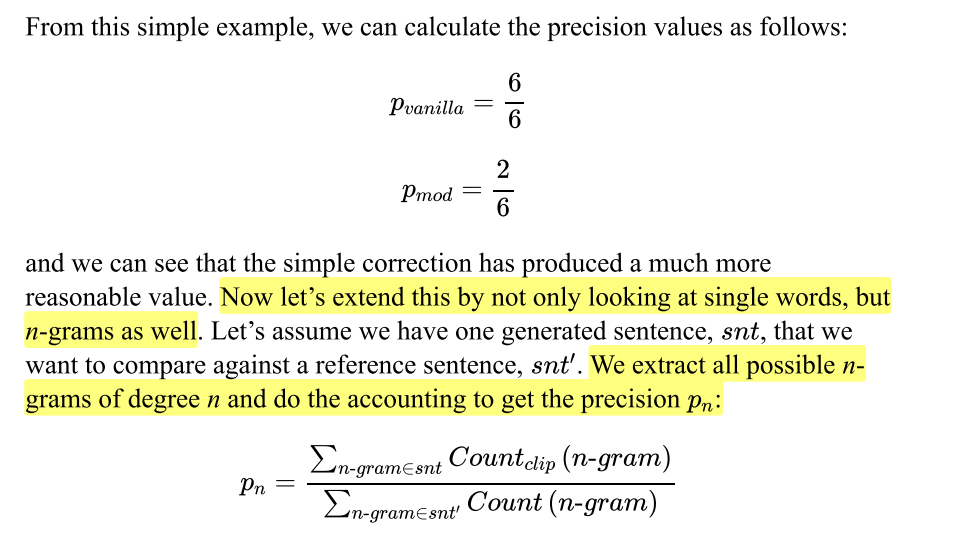

In order to avoid rewarding repetitive generations, the count in the numerator is clipped. What this means is that the occurrence count of an n-gram is capped at how many times it appears in the reference sentence. Also note that the definition of a sentence is not very strict in this equation, and if you had a generated text spanning multiple sentences you would treat it as one sentence.

In [ ]:
# hide_output
from datasets import load_metric

bleu_metric = load_metric("sacrebleu")

In [ ]:
import pandas as pd
import numpy as np
# voce pode adicionar sentenças com .add ou pode adicionar batches inteiros
# com add_batch()
bleu_metric.add(
    prediction="the the the the the the", reference=["the cat is on the mat"])
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)
results["precisions"] = [np.round(p, 2) for p in results["precisions"]]
pd.DataFrame.from_dict(results, orient="index", columns=["Value"])

# IPC o smooth value adiciona um pequeno termo ao numerador para que um n-gram faltante
# nao acarrete em um numerador zero
# para fins didaticos foi colocado como zero

# veja que como as outras palavras tem zero a saida do score foi zero (como nao colocamos um smooth value)


,Value
score,0.0
counts,"[2, 0, 0, 0]"
totals,"[6, 5, 4, 3]"
precisions,"[33.33, 0.0, 0.0, 0.0]"
bp,1.0
sys_len,6
ref_len,6


In [ ]:
bleu_metric.add(
    prediction="the cat is on mat", reference=["the cat is on the mat"])
results = bleu_metric.compute(smooth_method="floor", smooth_value=0)
results["precisions"] = [np.round(p, 2) for p in results["precisions"]]
pd.DataFrame.from_dict(results, orient="index", columns=["Value"])

,Value
score,57.893007
counts,"[5, 3, 2, 1]"
totals,"[5, 4, 3, 2]"
precisions,"[100.0, 75.0, 66.67, 50.0]"
bp,0.818731
sys_len,5
ref_len,6


Okay, vamos analisar esses resultados do cálculo do BLEU score, passo a passo.

**Contexto (Pelo Código):**

1.  **Predição (Prediction):** O texto gerado pelo seu modelo (ou o texto candidato) é `" the cat is on mat "` (5 palavras).
2.  **Referência (Reference):** O texto correto ou ideal é `[" the cat is on the mat "]` (6 palavras). Note que há apenas uma referência aqui.
3.  **Cálculo:** O código calcula o BLEU score comparando a `prediction` com a `reference`.

**Análise da Tabela de Resultados:**

A tabela mostra os componentes detalhados do cálculo do BLEU score:

1.  **`score: 57.893007`**
    * Este é o **resultado final do BLEU score**, geralmente apresentado numa escala de 0 a 100. É a métrica principal que você usaria para avaliar a qualidade (neste caso, a similaridade baseada em n-gramas) da `prediction` em relação à `reference`.

2.  **`sys_len: 5`**
    * É o comprimento (número de palavras/tokens) da **predição** (system length). " the cat is on mat " tem 5 palavras.

3.  **`ref_len: 6`**
    * É o comprimento (número de palavras/tokens) da **referência**. " the cat is on the mat " tem 6 palavras.

4.  **`bp: 0.818731`**
    * Esta é a **Penalidade por Brevidade (Brevity Penalty)**.
    * Como a predição (`sys_len=5`) é mais curta que a referência (`ref_len=6`), uma penalidade é aplicada. Se a predição fosse igual ou maior que a referência, o `bp` seria 1.0.
    * A fórmula é `exp(1 - ref_len / sys_len)`. Neste caso: `exp(1 - 6 / 5) = exp(1 - 1.2) = exp(-0.2) ≈ 0.8187`.
    * Essa penalidade reduz o score final porque a predição, sendo mais curta, pode artificialmente parecer ter alta precisão, mas está omitindo palavras.

5.  **`counts: [5, 3, 2, 1]`**
    * Representa a contagem de n-gramas **correspondentes** (após a "clipagem" da precisão modificada) para cada ordem de n-grama (1 a 4).
        * **Unigramas (1-gram):** 5 palavras da predição ("the", "cat", "is", "on", "mat") aparecem na referência. Count = 5.
        * **Bigramas (2-grams):** 3 bigramas da predição ("the cat", "cat is", "is on") aparecem na referência. "on mat" não aparece. Count = 3.
        * **Trigramas (3-grams):** 2 trigramas da predição ("the cat is", "cat is on") aparecem na referência. "is on mat" não aparece. Count = 2.
        * **Quadrigramas (4-grams):** 1 quadrigrama da predição ("the cat is on") aparece na referência. "cat is on mat" não aparece. Count = 1.

6.  **`totals: [5, 4, 3, 2]`**
    * Representa o número total de n-gramas na **predição** para cada ordem (1 a 4).
        * Unigramas: 5 ("the", "cat", "is", "on", "mat"). Total = 5.
        * Bigramas: 4 ("the cat", "cat is", "is on", "on mat"). Total = 4.
        * Trigramas: 3 ("the cat is", "cat is on", "is on mat"). Total = 3.
        * Quadrigramas: 2 ("the cat is on", "cat is on mat"). Total = 2.

7.  **`precisions: [100.0, 75.0, 66.67, 50.0]`**
    * Esta é a **precisão modificada** para cada ordem de n-grama, calculada como `counts[i] / totals[i]` (e aqui mostrada como porcentagem, provavelmente arredondada).
        * P1 = 5 / 5 = 1.0 (100.0%)
        * P2 = 3 / 4 = 0.75 (75.0%)
        * P3 = 2 / 3 ≈ 0.6667 (66.67%)
        * P4 = 1 / 2 = 0.5 (50.0%)
    * Mostra que a precisão diminui para n-gramas maiores porque a palavra "the" ausente na predição quebra as sequências mais longas.

**Como o Score Final é Calculado:**

O BLEU score final é o produto da Penalidade por Brevidade (BP) pela média geométrica das precisões dos n-gramas (P1 a P4).

1.  Média Geométrica (GM) = `(P1 * P2 * P3 * P4)^(1/4)`
    * GM = `(1.0 * 0.75 * (2/3) * 0.5)^(1/4)`
    * GM = `(0.25)^(1/4)` ≈ 0.7071
2.  Score = `BP * GM`
    * Score = `0.818731 * 0.7071` ≈ 0.57893
3.  Score (escala 0-100) = `0.57893 * 100` ≈ 57.893007

**Em Resumo:**

O BLEU score de ~57.89 indica uma correspondência razoável entre a predição e a referência em termos de palavras e pequenas frases compartilhadas. No entanto, o score não é perfeito (100) por dois motivos principais:

1.  A predição omitiu a palavra "the", o que diminuiu a precisão dos bigramas, trigramas e quadrigramas.
2.  A predição é mais curta que a referência, resultando em uma Penalidade por Brevidade (`bp` < 1) que reduziu ainda mais o score final.

### ROUGE

é mais usado para sumarização

In [ ]:
# hide_output
rouge_metric = load_metric("rouge")

In [ ]:
reference = dataset["train"][1]["highlights"]
records = []
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

for model_name in summaries:
    rouge_metric.add(prediction=summaries[model_name], reference=reference)
    score = rouge_metric.compute()
    rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
    records.append(rouge_dict)
pd.DataFrame.from_records(records, index=summaries.keys())

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.303571,0.090909,0.214286,0.232143
gpt2,0.187500,0.000000,0.125000,0.187500
t5,0.486486,0.222222,0.378378,0.486486
bart,0.582278,0.207792,0.455696,0.506329
pegasus,0.866667,0.655172,0.800000,0.833333


## Evaluating PEGASUS on the CNN/DailyMail Dataset

In [ ]:
# hide
# ignore this cell it is only to be able to start running the notebook here
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset, load_metric
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

dataset = load_dataset("cnn_dailymail", version="3.0.0")
rouge_metric = load_metric("rouge", cache_dir=None)
rouge_names = ["rouge1", "rouge2", "rougeL", "rougeLsum"]

  0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
def evaluate_summaries_baseline(dataset, metric,
                                column_text="article",
                                column_summary="highlights"):
    summaries = [three_sentence_summary(text) for text in dataset[column_text]]
    metric.add_batch(predictions=summaries,
                     references=dataset[column_summary])
    score = metric.compute()
    return score

In [ ]:
test_sampled = dataset["test"].shuffle(seed=42).select(range(1000))

score = evaluate_summaries_baseline(test_sampled, rouge_metric)
rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame.from_dict(rouge_dict, orient="index", columns=["baseline"]).T

,rouge1,rouge2,rougeL,rougeLsum
baseline,0.396061,0.173995,0.245815,0.361158


In [ ]:
from tqdm import tqdm
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

def chunks(list_of_elements, batch_size):
    """Yield successive batch-sized chunks from list_of_elements."""
    for i in range(0, len(list_of_elements), batch_size):
        yield list_of_elements[i : i + batch_size]

def evaluate_summaries_pegasus(dataset, metric, model, tokenizer,
                               batch_size=16, device=device,
                               column_text="article",
                               column_summary="highlights"):
    article_batches = list(chunks(dataset[column_text], batch_size))
    target_batches = list(chunks(dataset[column_summary], batch_size))

    for article_batch, target_batch in tqdm(
        zip(article_batches, target_batches), total=len(article_batches)):

        inputs = tokenizer(article_batch, max_length=1024,  truncation=True,
                        padding="max_length", return_tensors="pt")

        summaries = model.generate(input_ids=inputs["input_ids"].to(device),
                         attention_mask=inputs["attention_mask"].to(device),
                         length_penalty=0.8, num_beams=8, max_length=128)

        decoded_summaries = [tokenizer.decode(s, skip_special_tokens=True,
                                clean_up_tokenization_spaces=True)
               for s in summaries]
        decoded_summaries = [d.replace("<n>", " ") for d in decoded_summaries]
        metric.add_batch(predictions=decoded_summaries, references=target_batch)

    score = metric.compute()
    return score

In [ ]:
# hide_output
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

model_ckpt = "google/pegasus-cnn_dailymail"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt).to(device)
score = evaluate_summaries_pegasus(test_sampled, rouge_metric,
                                   model, tokenizer, batch_size=8)
rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

100%|██████████████████████████████████████████████████████████████████████████| 125/125 [10:39<00:00,  5.11s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.434381,0.210883,0.307195,0.373231


In [ ]:
# hide_input
pd.DataFrame(rouge_dict, index=["pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.434381,0.210883,0.307195,0.373231


## Training a Summarization Model

In [ ]:
# hide_output

# vamos ver a distribuição dos comprimentos dos inputs e outputs
dataset_samsum = load_dataset("samsum")
split_lengths = [len(dataset_samsum[split])for split in dataset_samsum]

print(f"Split lengths: {split_lengths}")
print(f"Features: {dataset_samsum['train'].column_names}")
print("\nDialogue:")
print(dataset_samsum["test"][0]["dialogue"])
print("\nSummary:")
print(dataset_samsum["test"][0]["summary"])

In [ ]:
# hide_input
print(f"Split lengths: {split_lengths}")
print(f"Features: {dataset_samsum['train'].column_names}")
print("\nDialogue:")
print(dataset_samsum["test"][0]["dialogue"])
print("\nSummary:")
print(dataset_samsum["test"][0]["summary"])

Split lengths: [14732, 819, 818]
Features: ['id', 'dialogue', 'summary']

Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact
Larry.


### Evaluating PEGASUS on SAMSum

In [ ]:
pipe_out = pipe(dataset_samsum["test"][0]["dialogue"])
print("Summary:")
print(pipe_out[0]["summary_text"].replace(" .<n>", ".\n"))

Summary:
Amanda: Ask Larry Amanda: He called her last time we were at the park together.
Hannah: I'd rather you texted him.
Amanda: Just text him .


In [ ]:
# hide_output
score = evaluate_summaries_pegasus(dataset_samsum["test"], rouge_metric, model,
                                   tokenizer, column_text="dialogue",
                                   column_summary="summary", batch_size=8)

rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=["pegasus"])

100%|██████████████████████████████████████████████████████████████████████████| 103/103 [07:48<00:00,  4.55s/it]


,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.296168,0.087803,0.229604,0.229514


In [ ]:
# hide_input
pd.DataFrame(rouge_dict, index=["pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.296168,0.087803,0.229604,0.229514


### Fine-Tuning PEGASUS

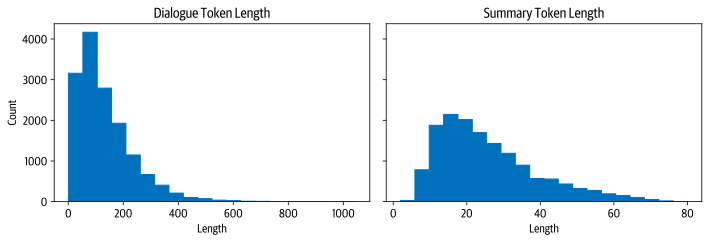

In [ ]:

# antes de processar vamos ver a distribuição dos comprimentso de entrada e saida
# vamos ver o numero de tokens
d_len = [len(tokenizer.encode(s)) for s in dataset_samsum["train"]["dialogue"]]#entradas
s_len = [len(tokenizer.encode(s)) for s in dataset_samsum["train"]["summary"]]# saidas

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].hist(d_len, bins=20, color="C0", edgecolor="C0")
axes[0].set_title("Dialogue Token Length")
axes[0].set_xlabel("Length")
axes[0].set_ylabel("Count")
axes[1].hist(s_len, bins=20, color="C0", edgecolor="C0")
axes[1].set_title("Summary Token Length")
axes[1].set_xlabel("Length")
plt.tight_layout()
plt.show()

In [ ]:
#hide_output
def convert_examples_to_features(example_batch):
    input_encodings = tokenizer(example_batch["dialogue"], max_length=1024,
                                truncation=True)

# no encoder decoder como nesses casos de sumarização, devemos diferenciar o tokenizer
# do encoder do decoder e por isso usamos tokenizer.as_target_tokenizer()
# assim o modelo sabe que está tokenizando a parte do decoder

#O bloco with tokenizer.as_target_tokenizer(): garante que a tokenização dos resumos
#(que servirão como labels para o treinamento) seja feita usando as configurações e regras apropriadas para sequências
#de destino, que podem ser sutilmente diferentes das regras para tokenizar as sequências de entrada
    with tokenizer.as_target_tokenizer():
        target_encodings = tokenizer(example_batch["summary"], max_length=128,
                                     truncation=True)

    return {"input_ids": input_encodings["input_ids"],
            "attention_mask": input_encodings["attention_mask"],
            "labels": target_encodings["input_ids"]}

dataset_samsum_pt = dataset_samsum.map(convert_examples_to_features,
                                       batched=True)
columns = ["input_ids", "labels", "attention_mask"]
dataset_samsum_pt.set_format(type="torch", columns=columns)

tokenizer.as_target_tokenizer(): Este é o gerenciador de contexto fornecido pelo objeto tokenizer da biblioteca Hugging Face transformers.

Propósito: Ele configura temporariamente o tokenizer para se comportar como se estivesse tokenizando um texto de destino (target/label), em oposição a um texto de entrada (input/source).

Por que isso é necessário? Para alguns modelos e tarefas, especialmente sequência-a-sequência (como sumarização ou tradução), pode haver pequenas diferenças na forma como as sequências de entrada e as sequências de destino devem ser tokenizadas. Isso pode incluir:

Tokens Especiais: Adição de diferentes tokens especiais de início ou fim de sequência.

Comportamento Interno: Ajustes sutis no processo de tokenização que são específicos para como o decoder do modelo espera receber os dados.

Como funciona: Ao entrar no bloco with, o gerenciador as_target_tokenizer() ajusta o estado interno do tokenizer. Dentro do bloco, qualquer chamada a tokenizer(...) usará essas configurações específicas de "alvo". Ao sair do bloco with, o gerenciador restaura automaticamente o estado anterior do tokenizer (o estado padrão para tokenizar entradas).

In [ ]:
#hide_input
# temos que deslocar 1 para o decoder ver apenas os valores anteriores e nao o valor atual ou futuro da label
#id teacher-forcing
#alt Decoder input and label alignemt for text generation.
#caption Decoder input and label alignemt for text generation.
text = ['PAD','Transformers', 'are', 'awesome', 'for', 'text', 'summarization']
rows = []
for i in range(len(text)-1):
    rows.append({'step': i+1, 'decoder_input': text[:i+1], 'label': text[i+1]})# text[:i+1]naopega i+1
pd.DataFrame(rows).set_index('step')

# ou seja, para o treinamento faz sentido entregar a primeira palavra de graça para o modelo treinar
# isso para evitar que ele demore muito aprendendo a iniciar uma frase sem ter nenhuma dica para prevê-la

,decoder_input,label
step,,
1,[PAD],Transformers
2,"[PAD, Transformers]",are
3,"[PAD, Transformers, are]",awesome
4,"[PAD, Transformers, are, awesome]",for
5,"[PAD, Transformers, are, awesome, for]",text
6,"[PAD, Transformers, are, awesome, for, text]",summarization


Ótima pergunta! O conceito de "Teacher Forcing" é fundamental para entender como muitos modelos sequência-a-sequência (seq2seq) são treinados eficientemente. Vamos detalhar o que o texto descreve:

1.  **Contexto: Modelos Seq2Seq (Encoder-Decoder)**
    * Modelos Seq2Seq são comuns em tarefas como tradução automática (inglês -> português) ou sumarização (artigo longo -> resumo curto).
    * Eles têm duas partes principais:
        * **Encoder:** Lê a sequência de entrada inteira (ex: a frase em inglês, o artigo) e a comprime em uma representação de contexto (geralmente vetores de estado oculto).
        * **Decoder:** Usa a representação do Encoder para gerar a sequência de saída (ex: a frase em português, o resumo) **token por token**, de forma autoregressiva.

2.  **Geração Autoregressiva do Decoder:**
    * "Autoregressivo" significa que a previsão de cada novo token depende dos tokens gerados anteriormente.
    * Para prever o token na posição `t+1`, o Decoder geralmente olha para:
        * A saída do Encoder (o contexto da entrada).
        * O token que ele *gerou* (ou deveria ter gerado) na posição `t`.
        * Seu próprio estado interno da etapa anterior.

3.  **O Dilema Durante o Treinamento:**
    * **Na *inferência* (quando usamos o modelo treinado):** O Decoder *tem* que usar o token que ele mesmo previu na etapa `t` como entrada para prever o token `t+1`. Se ele cometer um erro em `t`, esse erro pode se propagar e causar mais erros nas etapas seguintes (acumulação de erros).
    * **No *treinamento*:** Temos acesso à sequência de saída correta (os "labels" ou "ground truth"). Poderíamos simular a inferência e usar a própria previsão do modelo da etapa `t` como entrada para `t+1`. No entanto, isso pode tornar o treinamento muito lento e instável, especialmente no início, quando as previsões do modelo são ruins. O modelo pode nunca aprender direito se estiver sempre partindo de premissas erradas geradas por ele mesmo.

4.  **Teacher Forcing: A Solução Durante o Treinamento**
    * A estratégia de "Teacher Forcing" resolve esse dilema durante o *treinamento*.
    * **A Ideia Central:** Em vez de alimentar o Decoder com sua *própria* previsão da etapa anterior, nós o **forçamos** a usar o **token correto (o label/ground truth)** da etapa anterior como entrada para prever o próximo token.
    * É como se um "professor" (os dados de gabarito) estivesse constantemente corrigindo o aluno (o modelo), garantindo que ele sempre receba a entrada correta para o próximo passo, independentemente do que ele previu antes.

5.  **"Labels Shifted by One" (Rótulos Deslocados por Um):**
    * Esta é a parte crucial da implementação do Teacher Forcing. Para que o Decoder preveja o token `t+1`, ele precisa receber como entrada o token correto da posição `t`.
    * Imagine que a sequência de saída correta (labels) seja `[<s>, T1, T2, T3, </s>]` (onde `<s>` é um token de início e `</s>` é um token de fim).
    * Para treinar com Teacher Forcing, a **entrada do Decoder** será essa sequência deslocada uma posição para a direita (geralmente removendo o último token): `[<s>, T1, T2, T3]`.
    * O que o Decoder tenta prever (os **alvos** para a função de custo) é a sequência original a partir do primeiro token real: `[T1, T2, T3, </s>]`.
    * Veja como funciona passo a passo no treinamento:
        * **Passo 1:** Decoder recebe `<s>` (da entrada deslocada) e o output do Encoder. Ele deve prever `T1` (o primeiro alvo).
        * **Passo 2:** Decoder recebe `T1` (**o label correto da etapa anterior**, fornecido pela entrada deslocada) e o output do Encoder. Ele deve prever `T2` (o segundo alvo).
        * **Passo 3:** Decoder recebe `T2` (**o label correto da etapa anterior**) e o output do Encoder. Ele deve prever `T3` (o terceiro alvo).
        * **Passo 4:** Decoder recebe `T3` (**o label correto da etapa anterior**) e o output do Encoder. Ele deve prever `</s>` (o último alvo).

6.  **Comparação com Modelos Decoder-Only (GPT-2):**
    * O texto menciona que isso é similar a modelos como o GPT-2. Modelos decoder-only também são treinados para prever o próximo token com base nos tokens anteriores. Durante o treinamento deles, eles também recebem os tokens corretos do texto de treinamento como entrada para prever o próximo token (uma forma inerente de teacher forcing), mas sem a complexidade adicional de ter um Encoder.

**Benefícios e Desvantagens do Teacher Forcing:**

* **Benefício Principal:** Torna o treinamento muito mais estável e rápido, pois o modelo não se perde devido aos seus próprios erros iniciais. Ele sempre aprende a partir de um contexto "correto" no passo anterior.
* **Desvantagem Principal (Exposure Bias):** Cria uma discrepância entre o treinamento (onde o modelo sempre vê entradas corretas do passo anterior) e a inferência (onde ele vê suas próprias saídas, possivelmente erradas). Isso pode fazer com que o modelo seja menos robusto a erros durante a geração real. Existem técnicas para mitigar isso (como Scheduled Sampling), mas o Teacher Forcing puro é a forma mais comum de treinar.

**Em Resumo:** Teacher forcing é uma técnica de treinamento para modelos seq2seq onde, a cada passo da geração do decoder, em vez de usar a saída prevista pelo próprio modelo no passo anterior, utiliza-se o token correto (label/ground truth) do passo anterior como entrada. Isso é implementado alimentando o decoder com os "labels deslocados por um" e ajuda a estabilizar e acelerar o treinamento.

In [ ]:
from transformers import DataCollatorForSeq2Seq # datacoolarto para seq2seq
# mais usado em traduções e resumos

seq2seq_data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)


Olá! Com certeza. Os `Data Collators` são um componente fundamental, embora às vezes um pouco subestimado, no pipeline de treinamento e avaliação de modelos de linguagem, especialmente quando usamos bibliotecas como Hugging Face `transformers` com PyTorch ou TensorFlow.

Vamos à aula completa, considerando o contexto atual (3 de abril de 2025, Brasil).

---

**Aula Completa: Data Collators no Processamento de Linguagem Natural**

**1. O Problema: Dados de Tamanho Variável e Batches**

* **Natureza dos Dados de Texto:** Textos (frases, parágrafos, documentos) naturalmente têm comprimentos variáveis. Uma frase pode ter 5 palavras, outra 25.
* **Necessidade de Batches:** Para treinar modelos de Deep Learning eficientemente (especialmente em GPUs/TPUs), processamos os dados em lotes (batches) – pequenos conjuntos de exemplos de uma vez.
* **Exigência dos Modelos:** Frameworks como PyTorch e TensorFlow geralmente exigem que os tensores dentro de um único batch tenham dimensões consistentes para operações matriciais eficientes. Especificamente, para sequências (como texto tokenizado), isso significa que todas as sequências de `input_ids` (e máscaras de atenção, etc.) dentro de um batch precisam ter o **mesmo comprimento**.

**2. A Solução: Padding e o Data Collator**

* **Padding:** A técnica usada para fazer sequências de comprimentos diferentes terem o mesmo comprimento é o **padding**. Adicionamos tokens especiais (tokens de padding) ao final das sequências mais curtas até que todas atinjam o comprimento da sequência mais longa *dentro daquele batch*.
* **Máscara de Atenção (Attention Mask):** Para garantir que o modelo ignore esses tokens de padding adicionados (eles não contêm informação real), criamos uma "máscara de atenção". É um tensor com o mesmo formato dos `input_ids`, contendo `1` para tokens reais e `0` para tokens de padding. O modelo usa essa máscara para não prestar atenção aos tokens de padding.
* **Onde Entra o Data Collator?** É aqui que o Data Collator se torna essencial. Ele é um objeto responsável por pegar uma lista de exemplos individuais do seu dataset (geralmente já tokenizados) e:
    1.  **Agrupar** esses exemplos para formar um batch.
    2.  **Realizar o padding dinâmico** (dynamic padding): Calcular o comprimento máximo necessário *apenas para aquele batch específico* e aplicar padding às sequências mais curtas *dentro do batch*. Isso é muito mais eficiente do que fazer padding de todo o dataset para um comprimento máximo global.
    3.  **Criar** as máscaras de atenção correspondentes.
    4.  **Converter** os dados (listas de IDs, máscaras) em tensores do framework desejado (PyTorch tensors, TensorFlow tensors).
    5.  Opcionalmente, realizar **tarefas específicas** dependendo do tipo de Collator (ver abaixo).

**3. Como Funciona (Fluxo Típico com DataLoader):**

Quando você usa um `DataLoader` (do PyTorch, por exemplo) para iterar sobre seu dataset em batches, você pode especificar um `data_collator` através do argumento `collate_fn`.

1.  O `DataLoader` pega um conjunto de exemplos individuais do dataset (o tamanho do conjunto é o `batch_size`). Ex: `[exemplo1, exemplo2, exemplo3, exemplo4]` onde cada exemplo é um dicionário como `{'input_ids': [...], 'attention_mask': [...], 'labels': [...]}`.
2.  O `DataLoader` passa essa lista de exemplos para a função/objeto especificado em `collate_fn` (nosso `data_collator`).
3.  O `data_collator` examina todos os exemplos *nesta lista*.
4.  Ele encontra o comprimento máximo da sequência (`input_ids`, `labels`, etc.) *dentro desta lista*.
5.  Ele aplica padding a todas as sequências mais curtas nos campos relevantes (usando o ID do token de padding do tokenizer) até atingirem esse comprimento máximo.
6.  Ele gera/atualiza as `attention_mask`s correspondentes.
7.  Ele agrupa os dados de cada campo (todos os `input_ids` padronizados, todas as `attention_mask`s, todos os `labels`) e os converte em tensores (PyTorch, neste caso).
8.  Ele retorna um único dicionário onde as chaves são os nomes dos campos (`"input_ids"`, `"attention_mask"`, `"labels"`) e os valores são os tensores batcheados e padronizados, prontos para serem alimentados no modelo.

**4. Tipos Comuns de Data Collators (Hugging Face `transformers`):**

A biblioteca `transformers` oferece vários data collators pré-construídos para tarefas comuns:

* **`DataCollatorWithPadding`**:
    * O mais básico e frequentemente usado.
    * Recebe um `tokenizer` como argumento.
    * Aplica padding dinâmico aos `input_ids`, `attention_mask`, e quaisquer outros campos especificados para o comprimento máximo *no batch*.
    * Ideal para tarefas de classificação de texto ou outras tarefas onde apenas os inputs precisam de padding.
* **`DataCollatorForSeq2Seq`**:
    * Projetado para tarefas sequência-a-sequência (tradução, sumarização).
    * Recebe `tokenizer` e `model` como argumentos.
    * Aplica padding dinâmico tanto às entradas do encoder (`input_ids`, `attention_mask`) quanto às saídas/rótulos do decoder (`labels`).
    * Crucialmente, ele geralmente cria os `decoder_input_ids` deslocando os `labels` para a direita e adicionando o token de início de sequência do decoder. Ele também cuida para que os tokens de padding nos `labels` sejam ignorados na função de perda (geralmente substituindo-os por -100).
* **`DataCollatorForLanguageModeling`**:
    * Usado para treinar modelos de linguagem mascarados (MLM), como BERT.
    * Recebe `tokenizer` e `mlm_probability` (probabilidade de mascarar um token).
    * Além do padding, ele mascara aleatoriamente alguns tokens nos `input_ids` e cria os `labels` correspondentes (contendo os IDs originais apenas para os tokens mascarados, e -100 para os outros).
* **`DataCollatorForTokenClassification`**:
    * Para tarefas como Reconhecimento de Entidade Nomeada (NER) ou Part-of-Speech Tagging (POS).
    * Aplica padding aos `input_ids`, `attention_mask` e aos `labels` (que são sequências de rótulos, um para cada token de entrada).
    * Garante que os rótulos correspondentes aos tokens de padding sejam definidos como -100 para serem ignorados na perda.
* **`default_data_collator`**:
    * Uma função que tenta retornar um collator padrão (geralmente `DataCollatorWithPadding`) ou simplesmente converte a lista de exemplos em um batch de tensores se eles já tiverem o mesmo formato/tamanho.

**5. Conclusão:**

Data Collators são essenciais para lidar com a variabilidade de tamanho dos dados textuais ao treinar modelos de linguagem modernos. Eles automatizam o processo crucial de **padding dinâmico** e conversão para tensores, permitindo que os modelos processem dados em batches de forma eficiente. Escolher o Data Collator correto (como `DataCollatorWithPadding` ou `DataCollatorForSeq2Seq`) é importante para garantir que os dados sejam formatados corretamente para a tarefa e o modelo específicos.





In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir='pegasus-samsum', num_train_epochs=1, warmup_steps=500,
    per_device_train_batch_size=1, per_device_eval_batch_size=1,
    weight_decay=0.01, logging_steps=10, push_to_hub=True,
    evaluation_strategy='steps', eval_steps=500, save_steps=1e6,
    gradient_accumulation_steps=16)

# preparando os argumentos para o treinamento
#gradient_accumulation_steps acumula os gradientes
# como definimos um batch size muito pequeno (1) porque o modelo é grande, calcular a otimizaçaõ e os gradiente a cada batch nao funcionaria
#e o modelo demoraria a convergir. Para isso vamos acumular gradientes de 16 batches e aí sim vamos fazer
# os cálculo de otimização . Isso torna mais lento, mas salva muita gpu


#Step vs. Epoch:

#Uma Epoch (Época) é uma passagem completa por todo o conjunto de dados de treinamento.
#Um Step (Passo) é apenas uma única atualização dos pesos do modelo, baseada em um lote
 #(ou lote efetivo, no caso de acumulação de gradientes) de dados.

Claro! A classe `TrainingArguments` da biblioteca Hugging Face `transformers` é usada para encapsular todos os hiperparâmetros e configurações do processo de treinamento que será gerenciado pela classe `Trainer`.

Vamos analisar cada argumento fornecido na sua inicialização, considerando o contexto atual (3 de abril de 2025, Brasil):

1.  **`output_dir='pegasus-samsum'`**:
    * **Propósito:** Especifica o nome do diretório onde todos os artefatos do treinamento serão salvos.
    * **O que é salvo:** Checkpoints do modelo (pesos, estado do otimizador), configuração, logs de treinamento, resultados de avaliação e, eventualmente, o modelo final.
    * **Valor (`'pegasus-samsum'`):** Sugere que o objetivo é treinar ou ajustar um modelo Pegasus no dataset SAMSum, e os resultados serão salvos numa pasta com esse nome.

2.  **`num_train_epochs=1`**:
    * **Propósito:** Define o número total de vezes que o `Trainer` irá iterar sobre todo o conjunto de dados de treinamento. Uma época (epoch) significa passar por todos os exemplos de treino uma vez.
    * **Valor (`1`):** O treinamento executará apenas uma única passagem completa pelo dataset de treino. Isso pode ser útil para testes rápidos ou se o dataset for muito grande, mas geralmente é um número baixo para fine-tuning completo.

3.  **`warmup_steps=500`**:
    * **Propósito:** Controla a fase de "aquecimento" (warmup) do *learning rate scheduler* (agendador da taxa de aprendizado). Define o número de passos iniciais de treinamento durante os quais a taxa de aprendizado aumenta linearmente de 0 até o valor inicial configurado no otimizador.
    * **Por quê:** Ajuda a estabilizar o treinamento no início, evitando que gradientes muito grandes (comuns no começo) desestabilizem os pesos do modelo.
    * **Valor (`500`):** A taxa de aprendizado aumentará gradualmente durante os primeiros 500 passos de treinamento.

4.  **`per_device_train_batch_size=1`**:
    * **Propósito:** Define quantos exemplos de treinamento serão processados por *cada dispositivo* (GPU ou CPU) em um único passo de forward/backward propagation.
    * **Valor (`1`):** Um batch size muito pequeno por dispositivo. Isso geralmente é necessário quando o modelo é muito grande (como Pegasus) e consome muita memória VRAM da GPU, impedindo o uso de batch sizes maiores. Frequentemente usado em conjunto com `gradient_accumulation_steps`.

5.  **`per_device_eval_batch_size=1`**:
    * **Propósito:** Similar ao `per_device_train_batch_size`, mas define o número de exemplos por dispositivo durante a fase de *avaliação* (evaluation).
    * **Valor (`1`):** A avaliação será feita processando um exemplo de cada vez em cada dispositivo.

6.  **`weight_decay=0.01`**:
    * **Propósito:** Especifica a força da regularização L2 (conhecida como "weight decay"). Adiciona uma penalidade à função de custo proporcional ao quadrado do valor dos pesos do modelo.
    * **Por quê:** Ajuda a prevenir overfitting, desencorajando o modelo a aprender pesos excessivamente grandes.
    * **Valor (`0.01`):** Um valor comum e geralmente eficaz para weight decay.

7.  **`logging_steps=10`**:
    * **Propósito:** Determina a frequência (em número de passos de treinamento) com que as informações de progresso (como loss, learning rate, época atual, passo atual) são registradas (exibidas no console e/ou enviadas para ferramentas como TensorBoard ou Weights & Biases).
    * **Valor (`10`):** Informações de log serão geradas a cada 10 passos de treinamento.

8.  **`push_to_hub=True`**:
    * **Propósito:** Se definido como `True`, o `Trainer` tentará fazer o upload automático do modelo treinado (checkpoints, configuração final, tokenizer, logs) para o Hugging Face Hub ao final do treinamento (e possivelmente durante, dependendo da estratégia de salvamento). Requer que você esteja logado na sua conta Hugging Face (`huggingface-cli login`).
    * **Valor (`True`):** Indica a intenção de compartilhar o modelo ou salvá-lo de forma centralizada no Hub.

9.  **`evaluation_strategy='steps'`**:
    * **Propósito:** Define *quando* a avaliação no conjunto de dados de validação/teste deve ser realizada durante o treinamento.
    * **Valor (`'steps'`):** A avaliação ocorrerá a cada `eval_steps` passos de treinamento. Outras opções comuns são `'epoch'` (avaliar ao final de cada época) e `'no'` (não fazer avaliação durante o treinamento).

10. **`eval_steps=500`**:
    * **Propósito:** Usado em conjunto com `evaluation_strategy='steps'`. Define o número de passos de treinamento entre cada execução da avaliação.
    * **Valor (`500`):** O desempenho do modelo será avaliado no conjunto de avaliação a cada 500 passos de treinamento.

11. **`save_steps=1e6`**:
    * **Propósito:** Define a frequência (em número de passos de treinamento) com que um checkpoint do modelo (pesos, estados do otimizador e scheduler, etc.) é salvo no `output_dir`. Funciona em conjunto com `save_strategy` (que por padrão também é `'steps'`).
    * **Valor (`1e6` ou 1,000,000):** É um número muito alto. Na prática, isso significa que, se a estratégia de salvamento for baseada em passos, checkpoints intermediários provavelmente *não* serão salvos com base neste número (a menos que o treino tenha milhões de passos). O salvamento pode ocorrer apenas no final, ou se acionado por outra estratégia (como salvar a cada época, se `save_strategy='epoch'`). Pode indicar que o foco é salvar apenas o modelo final ou usar o `push_to_hub`.

12. **`gradient_accumulation_steps=16`**:
    * **Propósito:** Permite simular um tamanho de lote (batch size) efetivo maior do que caberia na memória da GPU de uma só vez.
    * **Como funciona:** Os gradientes são calculados para lotes menores (definidos por `per_device_train_batch_size`), mas em vez de atualizar os pesos do modelo imediatamente, esses gradientes são *acumulados* (somados) ao longo de `gradient_accumulation_steps`. A atualização dos pesos (passo do otimizador) só ocorre após acumular gradientes de `gradient_accumulation_steps` lotes menores.
    * **Efeito:** O tamanho efetivo do lote se torna `per_device_train_batch_size * num_gpus * gradient_accumulation_steps`.
    * **Valor (`16`):** Com `per_device_train_batch_size=1`, significa que os pesos do modelo serão atualizados a cada 16 passos, usando os gradientes acumulados de 16 exemplos (assumindo 1 GPU). Isso simula efetivamente um batch size de 16, permitindo usar os benefícios de um batch maior (gradientes mais estáveis) mesmo com memória limitada.

Em resumo, `TrainingArguments` é uma classe poderosa para configurar de forma detalhada e organizada todos os aspectos do ciclo de treinamento gerenciado pelo `Trainer` do Hugging Face.

In [ ]:
#hide_output
from huggingface_hub import notebook_login
# login para subir o modelo no HF
notebook_login()

In [ ]:
# hide_output
trainer = Trainer(model=model, args=training_args,
                  tokenizer=tokenizer, data_collator=seq2seq_data_collator,
                  train_dataset=dataset_samsum_pt["train"],
                  eval_dataset=dataset_samsum_pt["validation"])
# define o trainer

In [ ]:
# hide_output
# treina o modelo
trainer.train()

# fazemos a avaliação do modelo
score = evaluate_summaries_pegasus(
    dataset_samsum["test"], rouge_metric, trainer.model, tokenizer,
    batch_size=2, column_text="dialogue", column_summary="summary")

rouge_dict = dict((rn, score[rn].mid.fmeasure) for rn in rouge_names)
pd.DataFrame(rouge_dict, index=[f"pegasus"])

In [ ]:
# hide_input
#
pd.DataFrame(rouge_dict, index=[f"pegasus"])

,rouge1,rouge2,rougeL,rougeLsum
pegasus,0.427614,0.200571,0.340648,0.340738


In [ ]:
# hide_output
# salva o modelo
trainer.push_to_hub("Training complete!")

Saving model checkpoint to pegasus-samsum-test
Configuration saved in pegasus-samsum-test/config.json
Model weights saved in pegasus-samsum-test/pytorch_model.bin
tokenizer config file saved in pegasus-samsum-test/tokenizer_config.json
Special tokens file saved in pegasus-samsum-test/special_tokens_map.json
Dropping the following result as it does not have all the necessary field:
{'task': {'name': 'Sequence-to-sequence Language Modeling', 'type': 'text2text-generation'}, 'dataset': {'name': 'samsum', 'type': 'samsum', 'args': 'samsum'}}


'https://huggingface.co/lvwerra/pegasus-samsum-test/commit/236684ab026115ad5b9eb61f6ddbdaf3f07bddf8'

### Generating Dialogue Summaries

In [ ]:
# hide
import transformers
transformers.logging.set_verbosity_error()

In [ ]:
gen_kwargs = {"length_penalty": 0.8, "num_beams":8, "max_length": 128}
sample_text = dataset_samsum["test"][0]["dialogue"]
reference = dataset_samsum["test"][0]["summary"]
pipe = pipeline("summarization", model="transformersbook/pegasus-samsum")# usamos o modelo que salvamos

print("Dialogue:")
print(sample_text)
print("\nReference Summary:")
print(reference)
print("\nModel Summary:")
print(pipe(sample_text, **gen_kwargs)[0]["summary_text"]) # pixamos a saida do modelo

Dialogue:
Hannah: Hey, do you have Betty's number?
Amanda: Lemme check
Hannah: <file_gif>
Amanda: Sorry, can't find it.
Amanda: Ask Larry
Amanda: He called her last time we were at the park together
Hannah: I don't know him well
Hannah: <file_gif>
Amanda: Don't be shy, he's very nice
Hannah: If you say so..
Hannah: I'd rather you texted him
Amanda: Just text him 🙂
Hannah: Urgh.. Alright
Hannah: Bye
Amanda: Bye bye

Reference Summary:
Hannah needs Betty's number but Amanda doesn't have it. She needs to contact
Larry.

Model Summary:
Amanda can't find Betty's number. Larry called Betty last time they were at the
park together. Hannah wants Amanda to text Larry instead of calling Betty.


In [ ]:
custom_dialogue = """\
Thom: Hi guys, have you heard of transformers?
Lewis: Yes, I used them recently!
Leandro: Indeed, there is a great library by Hugging Face.
Thom: I know, I helped build it ;)
Lewis: Cool, maybe we should write a book about it. What do you think?
Leandro: Great idea, how hard can it be?!
Thom: I am in!
Lewis: Awesome, let's do it together!
"""
print(pipe(custom_dialogue, **gen_kwargs)[0]["summary_text"])

Thom, Lewis and Leandro are going to write a book about transformers. Thom
helped build a library by Hugging Face. They are going to do it together.


## Conclusion